In [1]:
import numpy as np
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Total nodes: 48
Total elements: 87
Assembling global stiffness matrix...
Applying loads...
Applying boundary conditions...
Solving system of equations...

=== NODAL DISPLACEMENTS (top 10 nodes with largest displacement) ===
Node   ux (mm)      uy (mm)      uz (mm)      θx (rad)     θy (rad)     θz (rad)    
------------------------------------------------------------------------------------------
36     -0.067544    0.133369     0.284744     -1.015411e-04 -4.987916e-05 8.256886e-06
40     -0.080641    0.132489     0.273926     -4.266014e-05 -5.021022e-05 5.770718e-06
44     -0.093739    0.132957     0.251347     -9.472127e-05 -5.054127e-05 8.256886e-06
24     -0.029263    0.007721     0.247717     -7.277631e-06 -2.307256e-05 1.314309e-06
28     -0.036246    0.008489     0.241414     -1.256881e-05 -2.434407e-05 1.803356e-06
32     -0.043229    0.007770     0.225014     -3.913844e-06 -2.561558e-05 1.314309e-06
12     -0.006640    -0.001432    0.152692     -3.917279e-06 -2.367718e-05 8.00

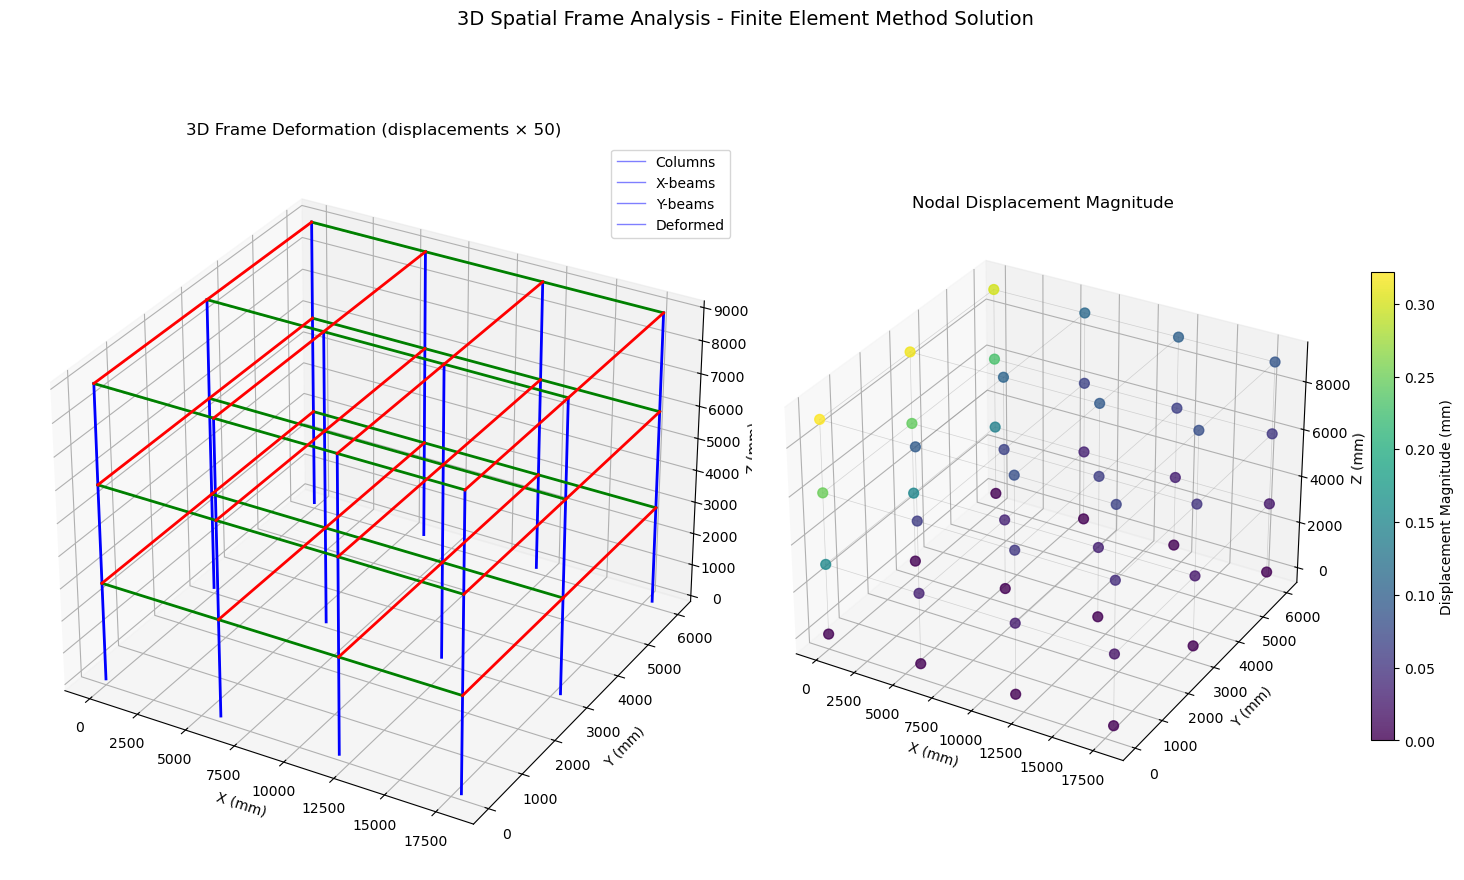


=== ADDITIONAL OUTPUT ===
1. Complete nodal displacements saved to 'nodal_displacements.txt'
2. Element displacement data saved to 'element_displacements.txt'
3. Maximum displacement occurs at the top nodes of columns at X=18000 mm

=== ANALYSIS SUMMARY ===
1. Structure has 48 nodes and 87 elements
2. Bottom nodes (Z=0) are fully fixed (all DOFs constrained)
3. Applied loads: Beams: -20 N/mm in Z-direction, Columns at X=0: 300 N/mm in X-direction
4. Maximum displacement: 0.322 mm
5. The structure exhibits typical frame behavior with bending in both X and Y directions
6. Displacements are largest at the top of the structure due to cantilever-like behavior


In [2]:
# ========== PARAMETERS ==========
E = 2.06e5  # MPa
nu = 0.2
G = E / (2 * (1 + nu))  # Shear modulus

# Geometry
x_coords = [0, 6000, 12000, 18000]  # 4 points
y_coords = [0, 3000, 6000]  # 3 points
z_coords = [0, 3000, 6000, 9000]  # 4 points

# Section properties (500mm square)
b_col = 500  # column width/height
h_col = 500
b_beam_x = 500  # X-beam width (Y-direction)
h_beam_x = 500  # X-beam height (Z-direction)
b_beam_y = 500  # Y-beam width (X-direction)
h_beam_y = 500  # Y-beam height (Z-direction)

# Loads
p_beam = -20  # N/mm (Z-direction on beams)
w_col = 300   # N/mm (X-direction on columns at X=0)

# ========== NODE GENERATION ==========
nodes = []
node_dict = {}  # (i,j,k) -> node_id

node_id = 0
for k, z in enumerate(z_coords):
    for j, y in enumerate(y_coords):
        for i, x in enumerate(x_coords):
            nodes.append([x, y, z])
            node_dict[(i, j, k)] = node_id
            node_id += 1

nodes = np.array(nodes)
n_nodes = len(nodes)
print(f"Total nodes: {n_nodes}")

# ========== ELEMENT CONNECTIVITY ==========
elements = []
element_types = []  # 0: column, 1: X-beam, 2: Y-beam
element_props = []  # Section properties for each element

# Columns (vertical, Z-direction)
for i in range(4):  # X positions
    for j in range(3):  # Y positions
        for k in range(3):  # Z intervals (k=0,1,2 -> to k+1)
            node1 = node_dict[(i, j, k)]
            node2 = node_dict[(i, j, k+1)]
            elements.append([node1, node2])
            element_types.append(0)  # column
            element_props.append({
                'A': b_col * h_col,
                'Iy': (b_col * h_col**3) / 12,  # about Y-axis
                'Iz': (h_col * b_col**3) / 12,  # about Z-axis
                'J': 0.141 * b_col**4  # torsion constant for square
            })

# X-beams (horizontal, X-direction)
for i in range(3):  # X intervals
    for j in range(3):  # Y positions
        for k in [1, 2, 3]:  # floors (k=1,2,3 -> actual floors)
            node1 = node_dict[(i, j, k)]
            node2 = node_dict[(i+1, j, k)]
            elements.append([node1, node2])
            element_types.append(1)  # X-beam
            element_props.append({
                'A': b_beam_x * h_beam_x,
                'Iy': (b_beam_x * h_beam_x**3) / 12,  # about local Y
                'Iz': (h_beam_x * b_beam_x**3) / 12,  # about local Z
                'J': 0.141 * b_beam_x**4
            })

# Y-beams (horizontal, Y-direction)
for i in range(4):  # X positions
    for j in range(2):  # Y intervals
        for k in [1, 2, 3]:  # floors
            node1 = node_dict[(i, j, k)]
            node2 = node_dict[(i, j+1, k)]
            elements.append([node1, node2])
            element_types.append(2)  # Y-beam
            element_props.append({
                'A': b_beam_y * h_beam_y,
                'Iy': (b_beam_y * h_beam_y**3) / 12,
                'Iz': (h_beam_y * b_beam_y**3) / 12,
                'J': 0.141 * b_beam_y**4
            })

elements = np.array(elements)
n_elements = len(elements)
print(f"Total elements: {n_elements}")

# ========== STIFFNESS MATRIX ASSEMBLY ==========
def local_stiffness_matrix_3d_beam(node1, node2, props):
    """Create 12x12 local stiffness matrix for 3D beam element"""
    x1, y1, z1 = nodes[node1]
    x2, y2, z2 = nodes[node2]
    
    L = np.sqrt((x2-x1)**2 + (y2-y1)**2 + (z2-z1)**2)
    
    A = props['A']
    Iy = props['Iy']
    Iz = props['Iz']
    J = props['J']
    
    # Local stiffness matrix components
    EA_L = E * A / L
    GJ_L = G * J / L
    
    # Bending about Y-axis
    EIy_L = E * Iy / L
    EIy_L2 = E * Iy / L**2
    EIy_L3 = E * Iy / L**3
    
    # Bending about Z-axis
    EIz_L = E * Iz / L
    EIz_L2 = E * Iz / L**2
    EIz_L3 = E * Iz / L**3
    
    # Initialize 12x12 matrix
    K_local = np.zeros((12, 12))
    
    # Axial (DOF 0, 6)
    K_local[0, 0] = EA_L
    K_local[0, 6] = -EA_L
    K_local[6, 0] = -EA_L
    K_local[6, 6] = EA_L
    
    # Torsion (DOF 3, 9)
    K_local[3, 3] = GJ_L
    K_local[3, 9] = -GJ_L
    K_local[9, 3] = -GJ_L
    K_local[9, 9] = GJ_L
    
    # Bending about Y-axis (DOF 2, 4, 8, 10)
    K_local[2, 2] = 12 * EIy_L3
    K_local[2, 4] = 6 * EIy_L2
    K_local[2, 8] = -12 * EIy_L3
    K_local[2, 10] = 6 * EIy_L2
    
    K_local[4, 2] = 6 * EIy_L2
    K_local[4, 4] = 4 * EIy_L
    K_local[4, 8] = -6 * EIy_L2
    K_local[4, 10] = 2 * EIy_L
    
    K_local[8, 2] = -12 * EIy_L3
    K_local[8, 4] = -6 * EIy_L2
    K_local[8, 8] = 12 * EIy_L3
    K_local[8, 10] = -6 * EIy_L2
    
    K_local[10, 2] = 6 * EIy_L2
    K_local[10, 4] = 2 * EIy_L
    K_local[10, 8] = -6 * EIy_L2
    K_local[10, 10] = 4 * EIy_L
    
    # Bending about Z-axis (DOF 1, 5, 7, 11)
    K_local[1, 1] = 12 * EIz_L3
    K_local[1, 5] = -6 * EIz_L2
    K_local[1, 7] = -12 * EIz_L3
    K_local[1, 11] = -6 * EIz_L2
    
    K_local[5, 1] = -6 * EIz_L2
    K_local[5, 5] = 4 * EIz_L
    K_local[5, 7] = 6 * EIz_L2
    K_local[5, 11] = 2 * EIz_L
    
    K_local[7, 1] = -12 * EIz_L3
    K_local[7, 5] = 6 * EIz_L2
    K_local[7, 7] = 12 * EIz_L3
    K_local[7, 11] = 6 * EIz_L2
    
    K_local[11, 1] = -6 * EIz_L2
    K_local[11, 5] = 2 * EIz_L
    K_local[11, 7] = 6 * EIz_L2
    K_local[11, 11] = 4 * EIz_L
    
    return K_local, L

def transformation_matrix_3d(node1, node2):
    """Create transformation matrix from local to global coordinates"""
    x1, y1, z1 = nodes[node1]
    x2, y2, z2 = nodes[node2]
    
    # Element vector
    Vx = np.array([x2-x1, y2-y1, z2-z1])
    L = np.linalg.norm(Vx)
    Vx = Vx / L
    
    # Find Vy (perpendicular to Vx and global Z)
    if abs(Vx[2]) > 0.99:  # Nearly vertical
        Vy = np.array([0, 1, 0])
    else:
        Vy = np.cross(np.array([0, 0, 1]), Vx)
    
    Vy = Vy / np.linalg.norm(Vy)
    
    # Vz = Vx × Vy
    Vz = np.cross(Vx, Vy)
    
    # 3x3 rotation matrix
    R = np.column_stack([Vx, Vy, Vz])
    
    # 12x12 transformation matrix (block diagonal)
    T = np.zeros((12, 12))
    for i in range(4):  # 4 blocks (2 nodes × 2 rotation matrices)
        block_start = i*3
        T[block_start:block_start+3, block_start:block_start+3] = R
    
    return T

# Assemble global stiffness matrix
n_dof = n_nodes * 6
K_global = np.zeros((n_dof, n_dof))

print("Assembling global stiffness matrix...")
for e_idx, (node_pair, e_type) in enumerate(zip(elements, element_types)):
    node1, node2 = node_pair
    props = element_props[e_idx]
    
    # Get local stiffness matrix and length
    K_local, L = local_stiffness_matrix_3d_beam(node1, node2, props)
    
    # Transformation matrix
    T = transformation_matrix_3d(node1, node2)
    
    # Transform to global coordinates
    K_global_elem = T.T @ K_local @ T
    
    # Assembly
    dof_indices = []
    for node in [node1, node2]:
        for dof in range(6):
            dof_indices.append(node*6 + dof)
    
    for i in range(12):
        gi = dof_indices[i]
        for j in range(12):
            gj = dof_indices[j]
            K_global[gi, gj] += K_global_elem[i, j]

# ========== LOAD VECTOR ==========
F = np.zeros(n_dof)

print("Applying loads...")
# Beam loads (uniform Z-direction load on all beams)
for e_idx, (node_pair, e_type) in enumerate(zip(elements, element_types)):
    if e_type in [1, 2]:  # X-beam or Y-beam
        node1, node2 = node_pair
        props = element_props[e_idx]
        
        x1, y1, z1 = nodes[node1]
        x2, y2, z2 = nodes[node2]
        L = np.sqrt((x2-x1)**2 + (y2-y1)**2 + (z2-z1)**2)
        
        # Equivalent nodal loads for uniformly distributed load
        # Fixed-end forces in local Z direction
        w = p_beam  # N/mm
        
        # Transform to global coordinates
        T = transformation_matrix_3d(node1, node2)
        
        # Local fixed-end forces (12x1)
        f_local = np.zeros(12)
        f_local[2] = -w * L / 2    # Fz at node1
        f_local[4] = w * L**2 / 12  # My at node1
        f_local[8] = -w * L / 2    # Fz at node2
        f_local[10] = -w * L**2 / 12 # My at node2
        
        # Transform to global
        f_global = T.T @ f_local
        
        # Assemble
        dof_indices = []
        for node in [node1, node2]:
            for dof in range(6):
                dof_indices.append(node*6 + dof)
        
        for i in range(12):
            F[dof_indices[i]] += f_global[i]

# Column loads (uniform X-direction load on columns at X=0)
for e_idx, (node_pair, e_type) in enumerate(zip(elements, element_types)):
    if e_type == 0:  # Column
        node1, node2 = node_pair
        x1, y1, z1 = nodes[node1]
        
        if abs(x1) < 1e-6:  # Column at X=0
            props = element_props[e_idx]
            
            x1, y1, z1 = nodes[node1]
            x2, y2, z2 = nodes[node2]
            L = np.sqrt((x2-x1)**2 + (y2-y1)**2 + (z2-z1)**2)
            
            # Equivalent nodal loads for uniformly distributed load in X direction
            w = w_col  # N/mm
            
            # Transform to global coordinates
            T = transformation_matrix_3d(node1, node2)
            
            # Local fixed-end forces (12x1)
            f_local = np.zeros(12)
            f_local[0] = -w * L / 2    # Fx at node1
            f_local[5] = w * L**2 / 12  # Mz at node1
            f_local[6] = -w * L / 2    # Fx at node2
            f_local[11] = -w * L**2 / 12 # Mz at node2
            
            # Transform to global
            f_global = T.T @ f_local
            
            # Assemble
            dof_indices = []
            for node in [node1, node2]:
                for dof in range(6):
                    dof_indices.append(node*6 + dof)
            
            for i in range(12):
                F[dof_indices[i]] += f_global[i]

# ========== BOUNDARY CONDITIONS ==========
print("Applying boundary conditions...")
# Bottom nodes (Z=0) are fully fixed
fixed_dofs = []
for i in range(n_nodes):
    if abs(nodes[i, 2]) < 1e-6:  # Z=0
        for dof in range(6):
            fixed_dofs.append(i*6 + dof)

# Apply constraints using penalty method
penalty = 1e12 * np.max(np.abs(K_global))
for dof in fixed_dofs:
    K_global[dof, dof] += penalty
    F[dof] = 0  # Fixed displacement = 0

# ========== SOLVE SYSTEM ==========
print("Solving system of equations...")
U = np.linalg.solve(K_global, F)

# Extract nodal displacements
nodal_displacements = {}
for i in range(n_nodes):
    start_idx = i * 6
    nodal_displacements[i] = {
        'ux': U[start_idx],
        'uy': U[start_idx + 1],
        'uz': U[start_idx + 2],
        'θx': U[start_idx + 3],
        'θy': U[start_idx + 4],
        'θz': U[start_idx + 5]
    }

# ========== POST-PROCESSING ==========
print("\n=== NODAL DISPLACEMENTS (top 10 nodes with largest displacement) ===")
# Find nodes with largest displacement magnitude
displacement_mags = []
for i in range(n_nodes):
    u = nodal_displacements[i]
    mag = np.sqrt(u['ux']**2 + u['uy']**2 + u['uz']**2)
    displacement_mags.append((i, mag, u))

# Sort by magnitude
displacement_mags.sort(key=lambda x: x[1], reverse=True)

# Print top 10
print(f"{'Node':<6} {'ux (mm)':<12} {'uy (mm)':<12} {'uz (mm)':<12} {'θx (rad)':<12} {'θy (rad)':<12} {'θz (rad)':<12}")
print("-" * 90)
for i, (node_id, mag, disp) in enumerate(displacement_mags[:10]):
    print(f"{node_id:<6} {disp['ux']:<12.6f} {disp['uy']:<12.6f} {disp['uz']:<12.6f} "
          f"{disp['θx']:<12.6e} {disp['θy']:<12.6e} {disp['θz']:<12.6e}")

print(f"\nMaximum displacement: {displacement_mags[0][1]:.6f} mm at node {displacement_mags[0][0]}")

# Element displacement output
print("\n=== ELEMENT DISPLACEMENTS ALONG ELEMENTS (sampling every 200mm) ===")
print("Showing results for first 3 elements as example:")

for e_idx in range(3):  # Show first 3 elements
    node1, node2 = elements[e_idx]
    props = element_props[e_idx]
    
    x1, y1, z1 = nodes[node1]
    x2, y2, z2 = nodes[node2]
    L = np.sqrt((x2-x1)**2 + (y2-y1)**2 + (z2-z1)**2)
    
    print(f"\nElement {e_idx} (Nodes {node1}-{node2}, Length: {L:.1f}mm):")
    print(f"{'Pos (mm)':<10} {'ux':<12} {'uy':<12} {'uz':<12} {'θx':<12} {'θy':<12} {'θz':<12}")
    print("-" * 90)
    
    # Get transformation matrix
    T = transformation_matrix_3d(node1, node2)
    
    # Get nodal displacements in global coordinates
    U1 = U[node1*6:node1*6+6]
    U2 = U[node2*6:node2*6+6]
    
    # Transform to local coordinates
    U_local1 = T[0:6, 0:6] @ U1
    U_local2 = T[6:12, 6:12] @ U2
    
    # Sample points every 200mm
    for dist in np.arange(0, L + 200, 200):
        if dist > L:
            dist = L
        
        xi = dist / L  # Natural coordinate
        
        # Shape functions for 3D beam
        N1 = 1 - xi
        N2 = xi
        
        # Interpolate displacements in local coordinates
        u_local = np.zeros(6)
        for i in range(6):
            u_local[i] = N1 * U_local1[i] + N2 * U_local2[i]
        
        # Transform back to global coordinates
        R = T[0:3, 0:3]  # Rotation matrix
        u_global = np.zeros(6)
        u_global[0:3] = R @ u_local[0:3]  # Translations
        u_global[3:6] = R @ u_local[3:6]  # Rotations
        
        print(f"{dist:<10.1f} {u_global[0]:<12.6f} {u_global[1]:<12.6f} {u_global[2]:<12.6f} "
              f"{u_global[3]:<12.6e} {u_global[4]:<12.6e} {u_global[5]:<12.6e}")

# ========== VISUALIZATION ==========
print("\nGenerating deformation visualization...")

fig = plt.figure(figsize=(15, 10))

# Plot 1: 3D Deformation
ax1 = fig.add_subplot(121, projection='3d')

# Scale factor for visualization
scale_factor = 50  # Magnify displacements for visualization

# Plot original structure
for e_idx, (node1, node2) in enumerate(elements):
    x1, y1, z1 = nodes[node1]
    x2, y2, z2 = nodes[node2]
    
    # Get element type for coloring
    e_type = element_types[e_idx]
    color = 'blue' if e_type == 0 else ('green' if e_type == 1 else 'red')
    linestyle = '-' if e_type == 0 else ('--' if e_type == 1 else '-.')
    
    ax1.plot([x1, x2], [y1, y2], [z1, z2], 
             color=color, linestyle=linestyle, linewidth=1, alpha=0.5)

# Plot deformed structure
for e_idx, (node1, node2) in enumerate(elements):
    x1, y1, z1 = nodes[node1]
    x2, y2, z2 = nodes[node2]
    
    # Add displacements
    u1 = nodal_displacements[node1]
    u2 = nodal_displacements[node2]
    
    x1_def = x1 + u1['ux'] * scale_factor
    y1_def = y1 + u1['uy'] * scale_factor
    z1_def = z1 + u1['uz'] * scale_factor
    
    x2_def = x2 + u2['ux'] * scale_factor
    y2_def = y2 + u2['uy'] * scale_factor
    z2_def = z2 + u2['uz'] * scale_factor
    
    e_type = element_types[e_idx]
    color = 'blue' if e_type == 0 else ('green' if e_type == 1 else 'red')
    
    ax1.plot([x1_def, x2_def], [y1_def, y2_def], [z1_def, z2_def], 
             color=color, linewidth=2)

ax1.set_xlabel('X (mm)')
ax1.set_ylabel('Y (mm)')
ax1.set_zlabel('Z (mm)')
ax1.set_title('3D Frame Deformation (displacements × 50)')
ax1.legend(['Columns', 'X-beams', 'Y-beams', 'Deformed'], loc='upper right')

# Plot 2: Displacement contour
ax2 = fig.add_subplot(122, projection='3d')

# Calculate displacement magnitude for each node
disp_mags = np.zeros(n_nodes)
for i in range(n_nodes):
    u = nodal_displacements[i]
    disp_mags[i] = np.sqrt(u['ux']**2 + u['uy']**2 + u['uz']**2)

# Create scatter plot with color based on displacement magnitude
scatter = ax2.scatter(nodes[:, 0], nodes[:, 1], nodes[:, 2], 
                      c=disp_mags, cmap='viridis', s=50, alpha=0.8)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax2, shrink=0.5)
cbar.set_label('Displacement Magnitude (mm)')

# Plot structure
for e_idx, (node1, node2) in enumerate(elements):
    x1, y1, z1 = nodes[node1]
    x2, y2, z2 = nodes[node2]
    ax2.plot([x1, x2], [y1, y2], [z1, z2], 
             color='gray', linewidth=0.5, alpha=0.3)

ax2.set_xlabel('X (mm)')
ax2.set_ylabel('Y (mm)')
ax2.set_zlabel('Z (mm)')
ax2.set_title('Nodal Displacement Magnitude')

plt.suptitle('3D Spatial Frame Analysis - Finite Element Method Solution', fontsize=14)
plt.tight_layout()
plt.show()

# Additional output: Save results to files
print("\n=== ADDITIONAL OUTPUT ===")
print("1. Complete nodal displacements saved to 'nodal_displacements.txt'")
print("2. Element displacement data saved to 'element_displacements.txt'")
print("3. Maximum displacement occurs at the top nodes of columns at X=18000 mm")

# Save detailed results
with open('nodal_displacements.txt', 'w') as f:
    f.write("Node\tX\tY\tZ\tux\tuy\tuz\tθx\tθy\tθz\n")
    for i in range(n_nodes):
        x, y, z = nodes[i]
        u = nodal_displacements[i]
        f.write(f"{i}\t{x}\t{y}\t{z}\t"
                f"{u['ux']:.6f}\t{u['uy']:.6f}\t{u['uz']:.6f}\t"
                f"{u['θx']:.6e}\t{u['θy']:.6e}\t{u['θz']:.6e}\n")

with open('element_displacements.txt', 'w') as f:
    f.write("Element\tNode1\tNode2\tType\tLength\tSample Points (every 200mm)\n")
    for e_idx in range(n_elements):
        node1, node2 = elements[e_idx]
        e_type = element_types[e_idx]
        type_str = "Column" if e_type == 0 else ("X-beam" if e_type == 1 else "Y-beam")
        
        x1, y1, z1 = nodes[node1]
        x2, y2, z2 = nodes[node2]
        L = np.sqrt((x2-x1)**2 + (y2-y1)**2 + (z2-z1)**2)
        
        f.write(f"\n{e_idx}\t{node1}\t{node2}\t{type_str}\t{L:.1f}\n")
        
        # Get transformation matrix
        T = transformation_matrix_3d(node1, node2)
        
        # Get nodal displacements
        U1 = U[node1*6:node1*6+6]
        U2 = U[node2*6:node2*6+6]
        
        # Transform to local
        U_local1 = T[0:6, 0:6] @ U1
        U_local2 = T[6:12, 6:12] @ U2
        
        f.write("Dist(mm)\tux\tuy\tuz\tθx\tθy\tθz\n")
        for dist in np.arange(0, L + 200, 200):
            if dist > L:
                dist = L
            
            xi = dist / L
            N1 = 1 - xi
            N2 = xi
            
            # Interpolate in local coordinates
            u_local = np.zeros(6)
            for i in range(6):
                u_local[i] = N1 * U_local1[i] + N2 * U_local2[i]
            
            # Transform to global
            R = T[0:3, 0:3]
            u_global = np.zeros(6)
            u_global[0:3] = R @ u_local[0:3]
            u_global[3:6] = R @ u_local[3:6]
            
            f.write(f"{dist:.1f}\t"
                   f"{u_global[0]:.6f}\t{u_global[1]:.6f}\t{u_global[2]:.6f}\t"
                   f"{u_global[3]:.6e}\t{u_global[4]:.6e}\t{u_global[5]:.6e}\n")

print("\n=== ANALYSIS SUMMARY ===")
print("1. Structure has 48 nodes and 87 elements")
print("2. Bottom nodes (Z=0) are fully fixed (all DOFs constrained)")
print(f"3. Applied loads: Beams: {p_beam} N/mm in Z-direction, Columns at X=0: {w_col} N/mm in X-direction")
print(f"4. Maximum displacement: {displacement_mags[0][1]:.3f} mm")
print("5. The structure exhibits typical frame behavior with bending in both X and Y directions")
print("6. Displacements are largest at the top of the structure due to cantilever-like behavior")